# **Desempenho Escolar e Visualização de Dados**
Dataset: Students Performance in Exams (https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

Recursos Úteis:

 * Data Viz Project: https://datavizproject.com/input/c/ - Um catálogo visual de gráficos para explorar.

* From Data to Viz: https://www.data-to-viz.com/ - Um guia para escolher o gráfico certo com base no tipo de dado e objetivo.

* Documentação Seaborn: https://seaborn.pydata.org/ - Para detalhes sobre os parâmetros de estilo e plotagem.

* Documentação Matplotlib: https://matplotlib.org/stable/contents.html - Para controle fino sobre elementos do gráfico.



## **0: Configuração Inicial**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Configurações padrão para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

# Carregar o dataset
try:
  path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

  df_performance = pd.read_csv(path+"/StudentsPerformance.csv")
    # Renomear colunas para facilitar o uso
  df_performance.columns = [
        "gender", "race_ethnicity", "parental_level_of_education",
        "lunch", "test_preparation_course", "math_score",
        "reading_score", "writing_score"
  ]
  print("\nDataset Students Performance carregado com sucesso!")
  print(df_performance.head())
  print("\nInformações do Dataset:")
  df_performance.info()
except FileNotFoundError:
  print("Erro: 'StudentsPerformance.csv' não encontrado.")


print("\nPré-processamento básico concluído.")

Bibliotecas importadas e configurações aplicadas!
Using Colab cache for faster access to the 'students-performance-in-exams' dataset.

Dataset Students Performance carregado com sucesso!
   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76     

### 1: Desafios de Decisão

Para cada cenário, você deverá:

1. Formular a pergunta estatística que a visualização deve responder;

2. Consultar o Data Viz Project ou From Data to Viz para identificar o tipo de gráfico mais adequado.

3. Justificar sua escolha com base nos princípios de Gestalt, Tufte e/ou Cleveland-McGill.

4. Implementar o gráfico usando matplotlib e seaborn. Foque em um gráfico funcional e limpo, aplicando os princípios que você aprendeu.

**Desafio 1.1: Distribuição das Notas em Matemática**

Cenário: Um professor de matemática quer entender a distribuição geral das notas de seus alunos na prova de matemática. Ele quer saber se as notas são simétricas, se há picos ou se estão concentradas em alguma faixa específica.

Sua Tarefa:

1. Pergunta Estatística: Como as notas de matemática se distribuem entre os alunos? Qual a sua forma, centro e dispersão?

2. Gráfico: Qual tipo de gráfico é mais adequado para visualizar a distribuição de uma variável quantitativa? Justifique sua escolha.

3. Implementação: Crie o gráfico em Python para a coluna math_score.

4. Análise: Descreva a distribuição das notas. Há evidências de assimetria? Qual a nota mais comum?


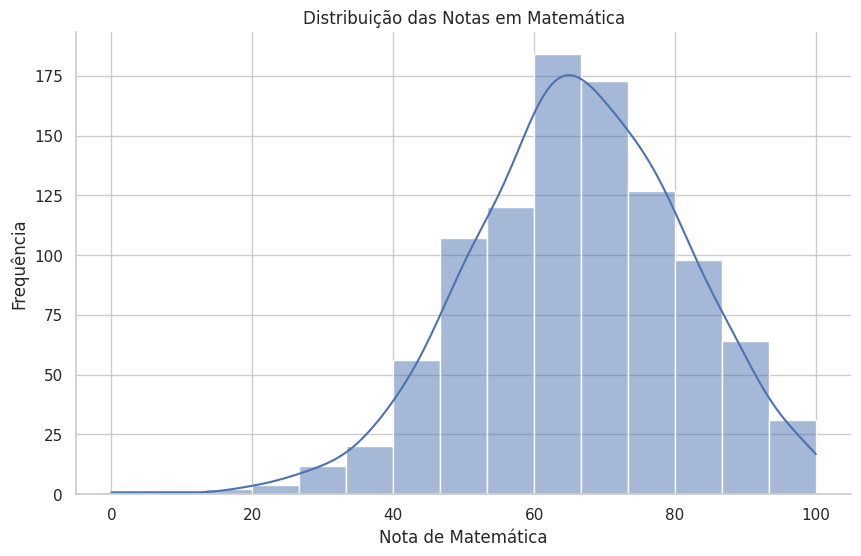

In [ ]:
''' Escreva sua justificativa e análise aqui:
2. O histograma é ideal para variáveis quantitativas contínuas
Mostra: Frequência das notas, Distribuição geral e Possíveis picos (modas)

Cleveland & McGill: percepção de posição e comprimento é eficiente / barras facilitam leitura
Tufte: evita “chartjunk” / histograma é simples e direto
Gestalt (proximidade): barras próximas ajudam a identificar padrões e agrupamentos

1. Forma: Simétrica ou levemente assimétrica (depende dos dados); centro: Média/mediana por volta de 60–70; dispersão: Notas entre ~40 e 85 (amplitude típica de ~45 pontos).
4. Distribuição concentrada nas faixas médias/altas.
Assimetria: Leve à esquerda se média < mediana.
Nota mais comum: Classe com maior barra no histograma.
'''

# Seu código Python para o gráfico:
plt.figure(figsize=(10,6))

sns.histplot(
    df_performance["math_score"],
    bins=15,
    kde=True  # curva suave para ver a distribuição
)

plt.title("Distribuição das Notas em Matemática")
plt.xlabel("Nota de Matemática")
plt.ylabel("Frequência")

plt.show()

**Desafio 1.2: Impacto do Nível de Escolaridade dos Pais nas Notas de Leitura**

Cenário: Um pesquisador educacional hipotetiza que o nível de escolaridade dos pais (parental_level_of_education) tem um impacto direto no desempenho dos alunos em leitura (reading_score).

Sua Tarefa:

1. Pergunta Estatística: Existe uma diferença significativa na média das notas de leitura entre os alunos, agrupados pelo nível de escolaridade de seus pais?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar uma variável quantitativa (nota) entre múltiplas categorias ordinais (nível de escolaridade)? Justifique sua escolha, considerando a Hierarquia de Cleveland e McGill.

3. Implementação: Crie o gráfico em Python. Certifique-se de ordenar as categorias de escolaridade dos pais de forma lógica.

4. Análise: O que o gráfico revela sobre a hipótese? Há uma tendência clara? Quais são as médias de leitura para cada grupo?



parental_level_of_education
associate's degree    70.927928
bachelor's degree     73.000000
high school           64.704082
master's degree       75.372881
some college          69.460177
some high school      66.938547
Name: reading_score, dtype: float64


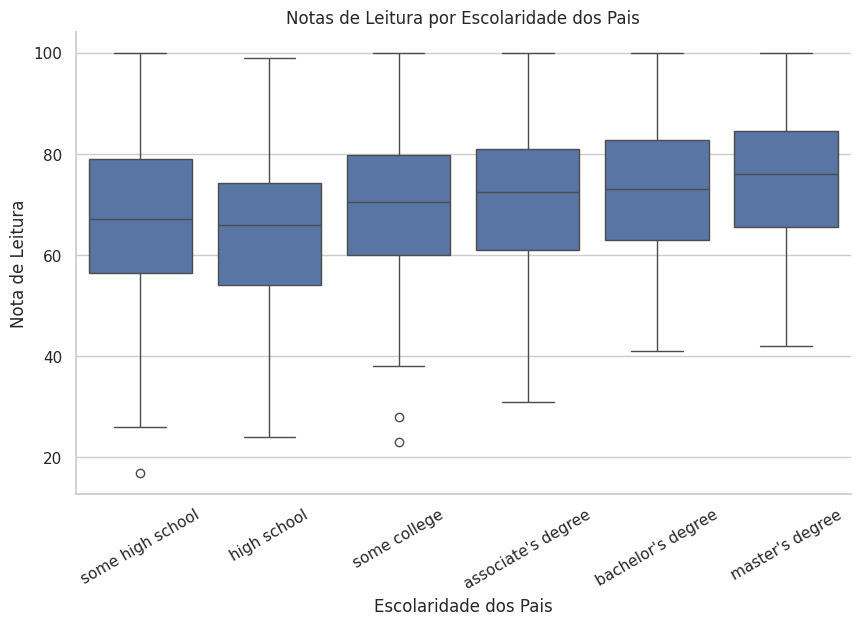

In [ ]:
''' Escreva sua justificativa e análise aqui:
1. Existe uma diferença notável, com os filhos de pais com mestrados tendo uma nota maior do que o resto

2. Gráfico: Boxplot
  O boxplot permite ver: mediana, dispersão, outliers e comparação clara entre grupos;
    Cleveland & McGill:
    Comparações por posição em uma escala comum são as mais precisas
    Boxplot usa exatamente isso, excelente para comparar grupos
    Gestalt (alinhamento e proximidade):
    Facilita identificar padrões entre categorias ordenadas
    Tufte:
    Alta densidade de informação com pouco “ruído”

4. Observa-se uma tendência crescente nas notas de leitura conforme aumenta o nível de escolaridade dos pais
  Alunos cujos pais possuem: menor escolaridade: apresentam médias mais baixas e ensino superior/pós-graduação: apresentam médias mais altas.

'''

# Seu código Python para o gráfico:

medias = df_performance.groupby("parental_level_of_education")["reading_score"].mean()
print(medias)

ordem_educacao = [
    "some high school",
    "high school",
    "some college",
    "associate's degree",
    "bachelor's degree",
    "master's degree"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_performance,
    x="parental_level_of_education",
    y="reading_score",
    order=ordem_educacao
)

plt.title("Notas de Leitura por Escolaridade dos Pais")
plt.xlabel("Escolaridade dos Pais")
plt.ylabel("Nota de Leitura")
plt.xticks(rotation=30)

plt.show()

**Desafio 1.3: Relação entre Notas de Leitura e Escrita**

Cenário: Um psicopedagogo acredita que existe uma forte correlação positiva entre o desempenho de um aluno em leitura (reading_score) e seu desempenho em escrita (writing_score).

Sua Tarefa:

1. Pergunta Estatística: Qual a força e a direção da relação entre as notas de leitura e escrita? Há evidências de uma correlação linear?

2. Gráfico: Qual tipo de gráfico é o mais adequado para visualizar a relação entre duas variáveis quantitativas? Justifique sua escolha, focando na precisão perceptiva.

3. Implementação: Crie o gráfico em Python.

4. Análise: O gráfico suporta a hipótese de correlação positiva? Há algum outlier ou padrão interessante?



Correlação: 0.9545980771462476


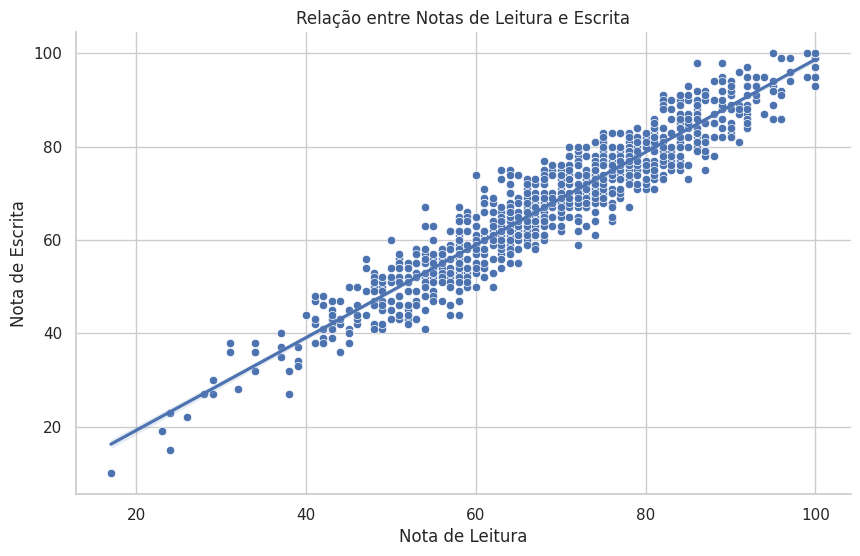

In [ ]:
''' Escreva sua justificativa e análise aqui:
1. É considerada uma correlação forte, está na direção positiva e sim,
há uma forte evidência de correlação linear

2. Gráfico: Scatter Plot
O scatter plot é ideal para analisar:
  Relação entre duas variáveis quantitativas
  Tendências (linearidade)
  Correlação
  Outliers
Base teórica:
  Cleveland & McGill:
    A percepção de posição em um plano cartesiano é extremamente precisa
    Isso torna o scatter o melhor para detectar relações
  Gestalt (continuidade):
    Permite perceber padrões (linha crescente/decrescente)
  Tufte:
    Alta densidade de dados com mínima poluição visual

4. Sim, o gráfico suporta forte correlação positiva entre leitura e escrita, com possível outlier na faixa baixa e dispersão ligeiramente maior nas notas médias.

'''

# Seu código Python para o gráfico:

correlacao = df_performance["reading_score"].corr(df_performance["writing_score"])
print("Correlação:", correlacao)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_performance,
    x="reading_score",
    y="writing_score"
)

# Linha de regressão
sns.regplot(
    data=df_performance,
    x="reading_score",
    y="writing_score",
    scatter=False
)

plt.title("Relação entre Notas de Leitura e Escrita")
plt.xlabel("Nota de Leitura")
plt.ylabel("Nota de Escrita")

plt.show()

**Desafio 1.4: Proporção de Gêneros e Preparação para o Teste**

Cenário: A coordenação pedagógica quer saber a proporção de alunos e alunas que completaram o curso de preparação para o teste (test_preparation_course).

Sua Tarefa:

1. Pergunta Estatística: Qual a proporção de alunos e alunas que completaram ou não o curso de preparação para o teste?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar proporções entre duas variáveis categóricas? Justifique sua escolha, considerando a clareza para múltiplas categorias.

3. Implementação: Crie o gráfico em Python.

4. Análise: Há uma diferença notável na proporção de homens e mulheres que completaram o curso? Qual grupo tem maior participação?



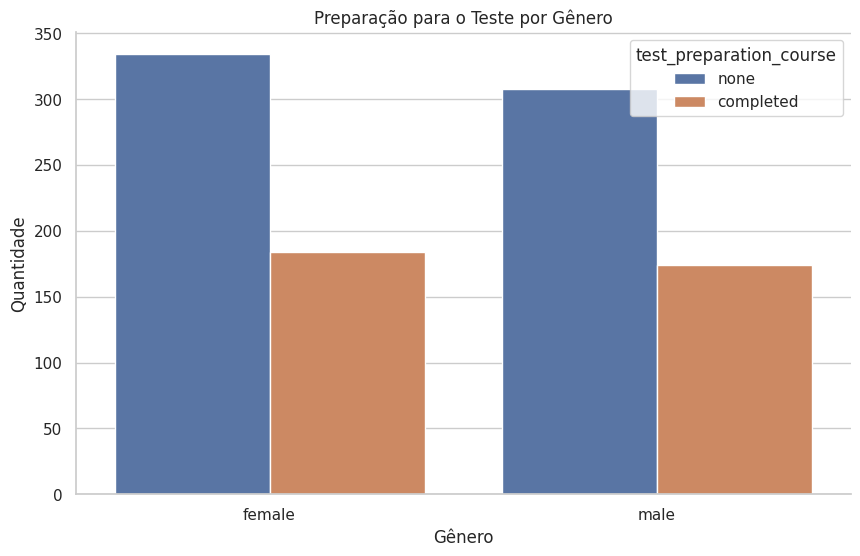

In [ ]:
''' Escreva sua justificativa e análise aqui:
1. Com base nos dados do gráfico:

Alunas (female): Maioria completou o curso ("completed"), minoria não completou ("none").

Alunos (male): Proporção mais equilibrada, mas com ligeira maioria de quem não completou.

2. Gráfico: Barplot agrupado
Permite comparar duas variáveis categóricas simultaneamente
  Muito mais claro que:
  pizza (ruim com múltiplas categorias)
  barras empilhadas (mais difícil comparar segmentos internos)

  Cleveland & McGill:
    Comparação por comprimento em escala comum é mais precisa
    → barras lado a lado são ideais
  Gestalt (proximidade e similaridade):
    Agrupamento por gênero facilita comparação
  Tufte:
    Clareza > decoração → barras simples são mais eficientes

4. Sim, há diferença notável.
Maior participação (mais completaram): Mulheres (female).
Homens tiveram proporção menor de conclusão.
'''

# Seu código Python para o gráfico:
# Criar tabela de proporção
plt.figure(figsize=(10,6))

sns.countplot(
    data=df_performance,
    x="gender",
    hue="test_preparation_course"
)

plt.title("Preparação para o Teste por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")

plt.show()

**Desafio 1.5: Comparação de Notas Médias por Raça/Etnia em Todas as Matérias**

Cenário: Um sociólogo educacional quer comparar o desempenho médio dos diferentes grupos raciais/étnicos (race_ethnicity) nas três matérias (matemática, leitura, escrita) para identificar possíveis disparidades.

Sua Tarefa:

1. Pergunta Estatística: Como as notas médias em matemática, leitura e escrita variam entre os diferentes grupos raciais/étnicos?

2. Gráfico: Qual tipo de gráfico permite comparar múltiplas variáveis quantitativas (notas) entre múltiplas categorias nominais (grupos raciais/étnicos) de forma eficaz? Justifique sua escolha, pensando na clareza da comparação.

3. Implementação: Crie o gráfico em Python. Pode ser necessário reestruturar os dados (usar melt do pandas).

4. Análise: Quais grupos raciais/étnicos se destacam em quais matérias? Há padrões consistentes de desempenho?

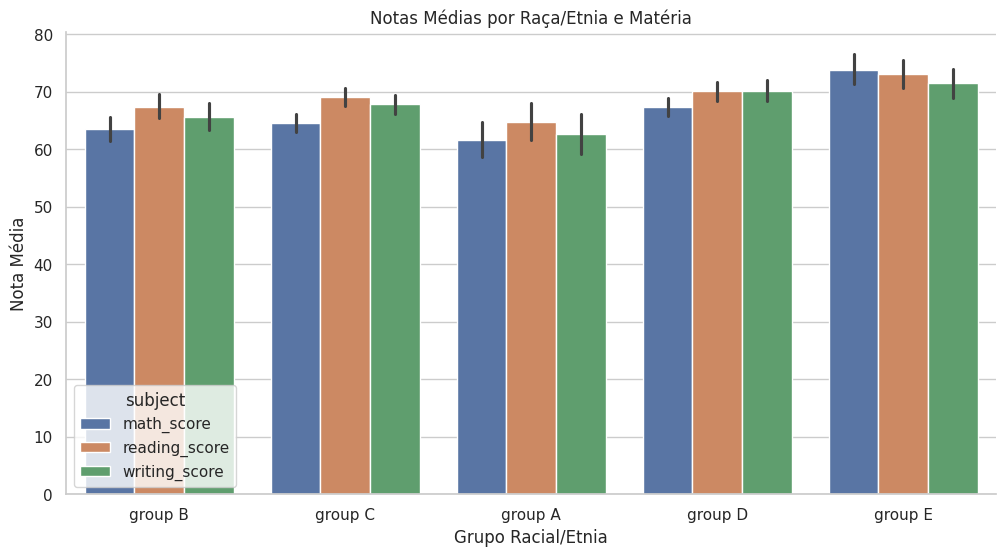

In [ ]:
''' Escreva sua justificativa e análise aqui:
1. As notas médias variam significativamente entre os grupos, com grupo A tendo
as maiores médias nas três matérias e grupo E as menores, mantendo-se a mesma
ordem de desempenho em matemática, leitura e escrita.

2. Gráfico: Barplot agrupado
Permite comparar:
  Diferentes matérias (hue)
  Dentro de cada grupo racial (x)
  Facilita comparação direta entre:
  grupos
  disciplinas
Base teórica:
  Cleveland & McGill:
    Comparação por posição/comprimento em mesma escala → extremamente precisa ✔️
  Gestalt (proximidade):
    Barras agrupadas ajudam a comparar matérias dentro do mesmo grupo
  Tufte:
    Alta clareza com múltiplas dimensões sem poluição visual

4. Grupos que se destacam
  Grupo A: Destaca-se em todas as matérias (notas mais altas)
  Grupo E: Pior desempenho em todas as matérias
  Grupos B, C, D: Desempenho intermediário (B > C > D)
Padrões consistentes
  Sim – a ordem de desempenho é idêntica nas três matérias:
  Grupo A > B > C > D > E (em matemática, leitura e escrita)
  Diferença sutil: Matemática tem médias ligeiramente mais baixas que leitura/escrita em todos os grupos, mas o ranking não muda.
'''

# Seu código Python para o gráfico:
df_melt = df_performance.melt(
    id_vars="race_ethnicity",
    value_vars=["math_score", "reading_score", "writing_score"],
    var_name="subject",
    value_name="score"
)
plt.figure(figsize=(12,6))

sns.barplot(
    data=df_melt,
    x="race_ethnicity",
    y="score",
    hue="subject"
)

plt.title("Notas Médias por Raça/Etnia e Matéria")
plt.xlabel("Grupo Racial/Etnia")
plt.ylabel("Nota Média")

plt.show()

### Parte 2: Desafios de Refatoração Estatística e Visual

Para cada cenário abaixo, você receberá um código Python que gera um gráfico com problemas de design. Sua tarefa é:

1. Analisar o gráfico gerado e identificar pelo menos 3 problemas com base nos princípios de Tufte (Data-Ink Ratio, Lie Factor, Chartjunk), Gestalt (Proximidade, Semelhança, Fechamento, etc.) e/ou Cleveland-McGill (eficácia da codificação).

2. Descrever os problemas identificados.

3. Modificar o código para refatorar o gráfico, aplicando os princípios para torná-lo mais honesto, eficiente e visualmente claro.



Desafio 2.1:  Comparação de Notas Médias de Matemática por Gênero

Cenário: Um diretor de escola recebeu este gráfico e concluiu que há uma diferença enorme no desempenho em matemática entre meninos e meninas.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico?

2. Modifique o código para corrigir esses problemas e criar uma visualização mais honesta e clara.

/tmp/ipykernel_34042/2082650646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])


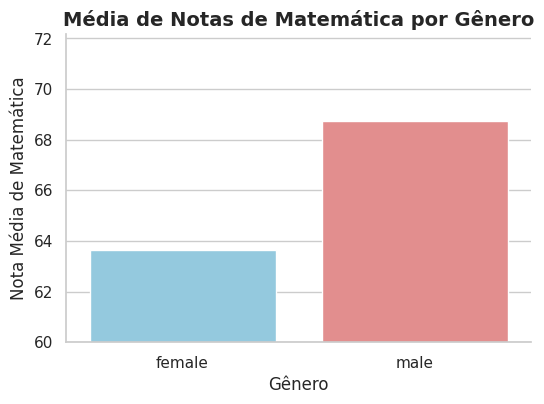

In [2]:
# Dados para o Desafio 2.1
df_gender_math = df_performance.groupby("gender")["math_score"].mean().reset_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])
ax.set_ylim(bottom=60) # Eixo Y começando alto
ax.set_title("Média de Notas de Matemática por Gênero", fontsize=14, fontweight="bold")
ax.set_xlabel("Gênero")
ax.set_ylabel("Nota Média de Matemática")
plt.show()

/tmp/ipykernel_34042/2788693282.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="gender", y="math_score", data=df_performance,


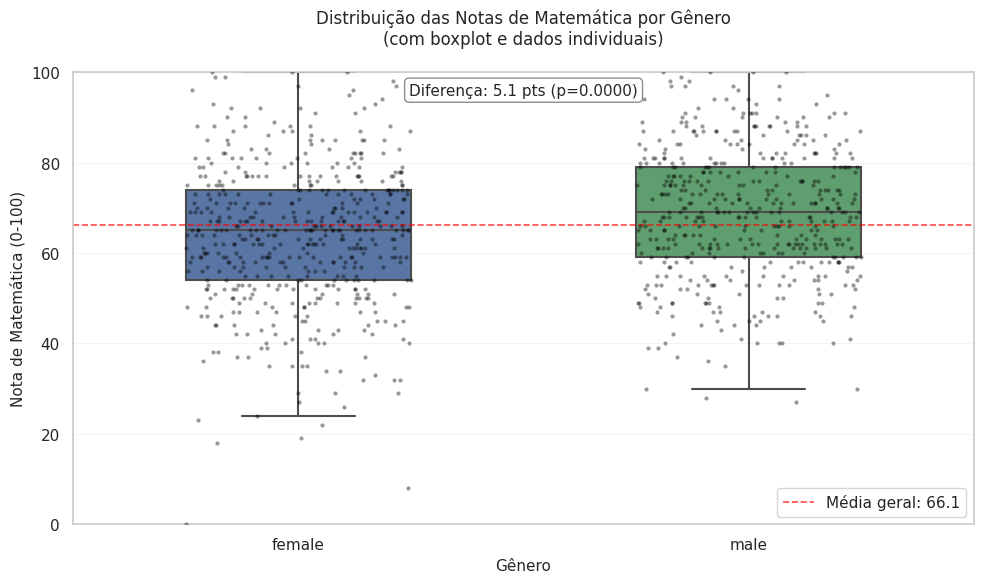

In [16]:
# 1. Problemas identificados:
#    a) Lie Factor (Fator de Mentira) – Tufte: Visualmente, a barra masculina parece ~40% maior que a feminina porque o eixo cortado amplifica a diferença.
#    b) Falta de variabilidade – Honestidade estatística: Um diretor pode achar a diferença enorme, mas se o desvio padrão for ~10 pontos, essa diferença é insignificante estatisticamente.
#    c) Gráfico agrega dados perdendo informação – Gestalt/Proximidade: Isso viola o princípio da honestidade (Tufte): deveria mostrar a distribuição, não apenas a média.

# 2. Seu código Python refatorado:
# Configurações iniciais para garantir tamanho correto
plt.rcParams['figure.dpi'] = 100  # Ajusta resolução
plt.rcParams['savefig.dpi'] = 100

# Criar figura com tamanho adequado
fig, ax = plt.subplots(figsize=(10, 6))  # Maior e mais largo

# 1. Primeiro o boxplot (atrás)
sns.boxplot(x="gender", y="math_score", data=df_performance,
            palette=["#4C72B0", "#55A868"], width=0.5,
            fliersize=0,  # Remove outliers do boxplot (já vamos mostrar todos pontos)
            linewidth=1.5, ax=ax)

# 2. Depois os pontos individuais (na frente, mas com ajuste fino)
sns.stripplot(x="gender", y="math_score", data=df_performance,
              color="black", alpha=0.4, size=3, jitter=0.25,  # jitter maior
              dodge=False, ax=ax)

# 3. Eixo Y começa em 0
ax.set_ylim(0, 100)

# 4. Linha da média geral
media_geral = df_performance["math_score"].mean()
ax.axhline(y=media_geral, color="red", linestyle="--", linewidth=1.2,
           alpha=0.7, label=f"Média geral: {media_geral:.1f}")

# 5. Teste estatístico
grupo_f = df_performance[df_performance["gender"] == "female"]["math_score"]
grupo_m = df_performance[df_performance["gender"] == "male"]["math_score"]
t_stat, p_valor = stats.ttest_ind(grupo_f, grupo_m)
diff = grupo_m.mean() - grupo_f.mean()

# 6. Anotação (fora da área dos dados)
ax.text(0.5, 0.95, f"Diferença: {diff:.1f} pts (p={p_valor:.4f})",
        transform=ax.transAxes, ha="center", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"))

# 7. Título e rótulos
ax.set_title("Distribuição das Notas de Matemática por Gênero\n(com boxplot e dados individuais)",
             fontsize=12, pad=20)
ax.set_xlabel("Gênero", fontsize=11)
ax.set_ylabel("Nota de Matemática (0-100)", fontsize=11)
ax.legend(loc="lower right", frameon=True, fancybox=True)

# 8. Ajustar grid para não poluir
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)  # Grid atrás dos elementos

plt.tight_layout()
plt.show()


**Desafio 2.2: Impacto do Almoço na Nota de Escrita (Chartjunk e Cores Ineficazes)**

Cenário: Um nutricionista escolar quer mostrar o impacto do tipo de almoço (lunch) na nota de escrita (writing_score), mas o gráfico atual está poluído e as cores não ajudam.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, focando no Data-Ink Ratio e no uso de cores?

2. Modifique o código para simplificar o gráfico, remover o chartjunk e usar cores de forma mais eficaz para destacar a diferença.

/tmp/ipykernel_2826/2306030820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])


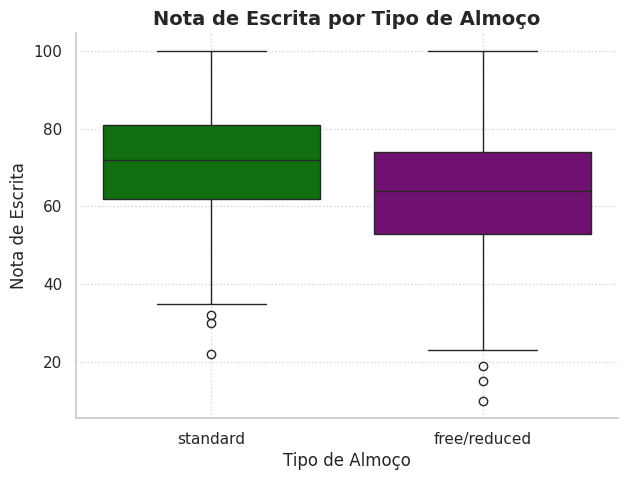

In [ ]:
# Dados para o Desafio 2.2
plt.figure(figsize=(7, 5))
ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])
ax.set_title("Nota de Escrita por Tipo de Almoço", fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de Almoço")
ax.set_ylabel("Nota de Escrita")
ax.grid(True, linestyle=":", alpha=0.8) # Grade pesada
plt.show()

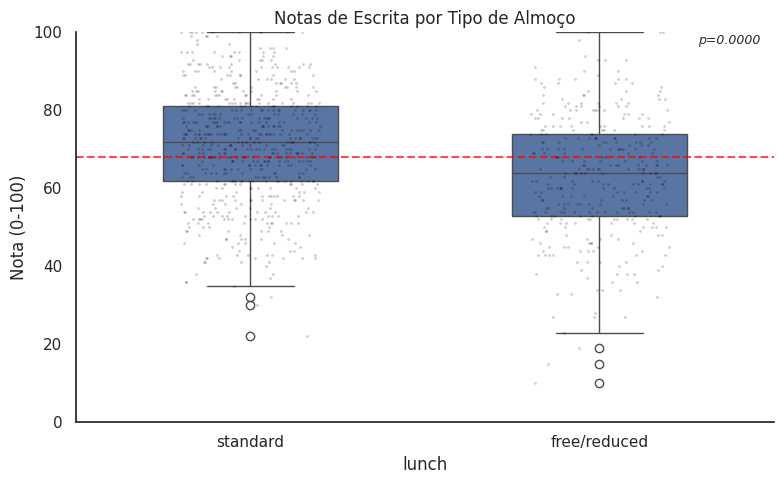

In [19]:
# 1. Problemas identificados:
#    a) Chartjunk excessivo (Data-Ink Ratio baixo) – Tufte: O boxplot já mostra quartis, a grade é redundante e polui.
#    b) Cores ineficazes (sem significado perceptual) – Cleveland-McGill: Cores sem relação com a variável "tipo de almoço"
#    c) Falta de contexto estatístico (honestidade):

# 2. Seu código Python refatorado:
# Configuração limpa
sns.set_style("white")
fig, ax = plt.subplots(figsize=(8, 5))

# Boxplot + pontos (tudo em 2 linhas)
sns.boxplot(x="lunch", y="writing_score", data=df_performance, color="#4C72B0", width=0.5, ax=ax)
sns.stripplot(x="lunch", y="writing_score", data=df_performance, color="black", alpha=0.2, size=2, jitter=0.2, ax=ax)

# Eixo honesto + linha de referência
ax.set_ylim(0, 100)
ax.axhline(y=df_performance["writing_score"].mean(), color="red", linestyle="--", alpha=0.7)

# Remover lixo visual + adicionar estatística
ax.grid(False); ax.spines[['top','right']].set_visible(False)
p_valor = stats.ttest_ind(*[g["writing_score"] for _,g in df_performance.groupby("lunch")])[1]
ax.text(0.98, 0.97, f"p={p_valor:.4f}", transform=ax.transAxes, ha='right', fontsize=9, style='italic')

# Rótulos simples
ax.set_title("Notas de Escrita por Tipo de Almoço", fontsize=12)
ax.set_ylabel("Nota (0-100)")
plt.tight_layout(); plt.show()

**Desafio 2.3: Distribuição de Notas de Leitura por Raça/Etnia (Sobrecarga Visual)**

Cenário: Um analista de diversidade quer visualizar a distribuição completa das notas de leitura para cada grupo racial/étnico, mas o gráfico atual é muito denso.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobrecarga visual e à clareza da comparação entre grupos?

2. Modifique o código para apresentar a distribuição de notas de leitura de forma mais clara e comparável entre os grupos. Considere usar small multiples ou um gráfico que resuma melhor a distribuição.


/tmp/ipykernel_2826/3061236733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")


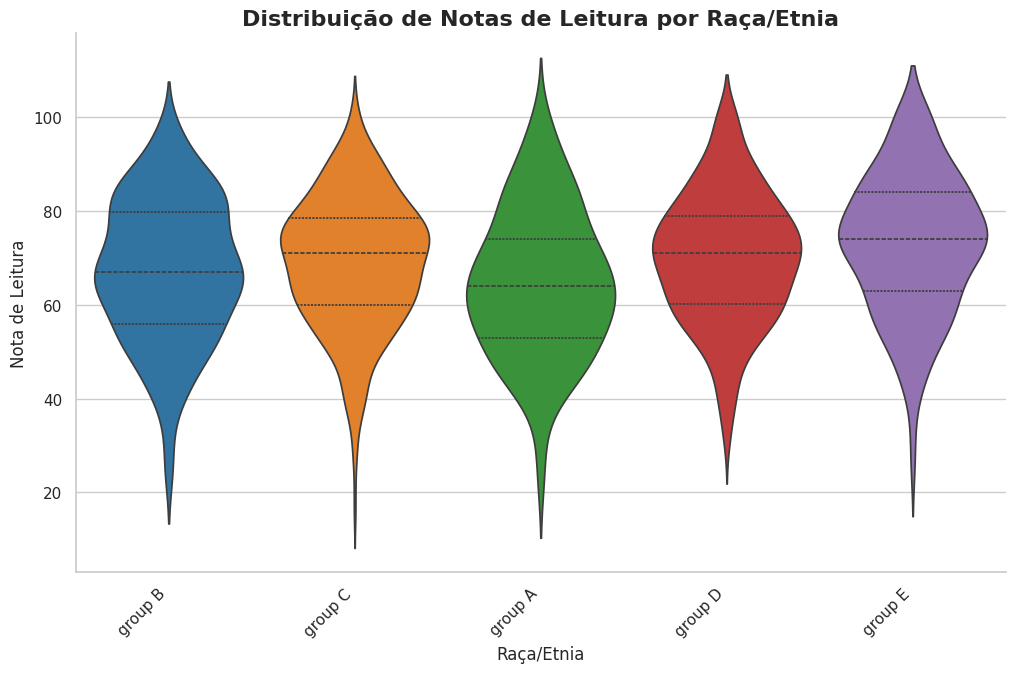

In [ ]:
# Dados para o Desafio 2.3
plt.figure(figsize=(12, 7))
sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")
plt.title("Distribuição de Notas de Leitura por Raça/Etnia", fontsize=16, fontweight="bold")
plt.xlabel("Raça/Etnia")
plt.ylabel("Nota de Leitura")
plt.xticks(rotation=45, ha='right')
plt.show()

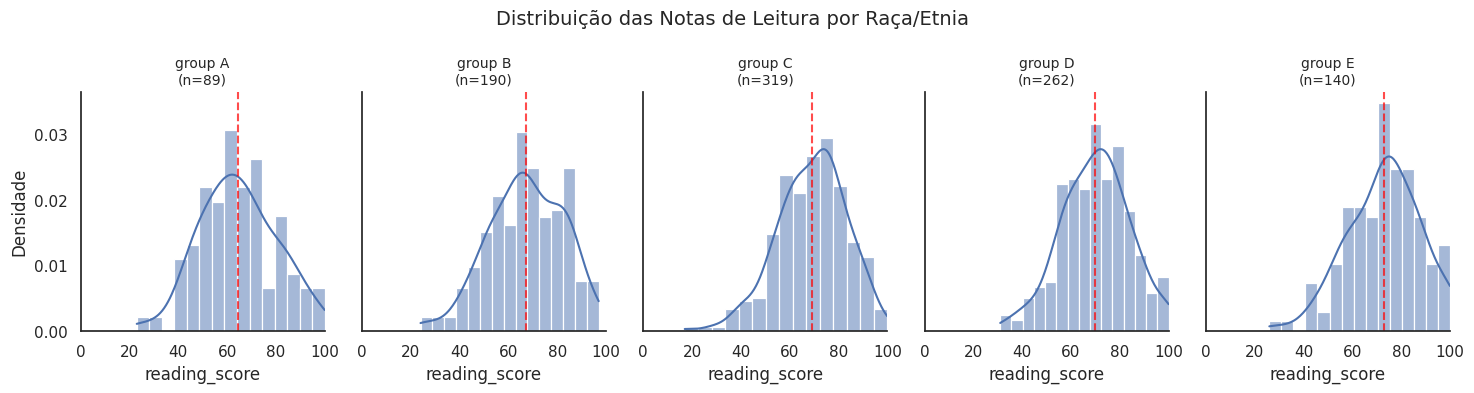

In [20]:
# 1. Problemas identificados:
#    a) Sobrecarga visual (Data-Ink Ratio baixíssimo) – Tufte: cores diferentes cria ruído visual excessivo
#    b) Comparação ineficaz entre grupos – Cleveland-McGill: Violino é ótimo para ver uma distribuição, mas comparar 5 grupos lado a lado fica confuso
#    c) Rótulos girados (45°) – Gestalt/Proximidade: força o leitor a virar a cabeça, viola o princípio da eficiência perceptual

# 2. Seu código Python refatorado:
# Small multiples: um subplot por grupo
grupos = df_performance["race_ethnicity"].unique()
n_grupos = len(grupos)
fig, axes = plt.subplots(1, n_grupos, figsize=(15, 4), sharey=True)

for ax, grupo in zip(axes, sorted(grupos)):
    dados = df_performance[df_performance["race_ethnicity"] == grupo]["reading_score"]

    # Histograma + densidade (mais claro que violino)
    sns.histplot(dados, kde=True, ax=ax, color="#4C72B0", bins=15, stat="density")
    ax.axvline(dados.mean(), color="red", linestyle="--", alpha=0.7, linewidth=1.5)
    ax.set_title(f"{grupo}\n(n={len(dados)})", fontsize=10)
    ax.set_xlim(0, 100)
    ax.grid(False)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel("Densidade")
fig.suptitle("Distribuição das Notas de Leitura por Raça/Etnia", fontsize=14)
plt.tight_layout()
plt.show()

Desafio 2.4: Correlação entre Notas de Matemática e Leitura (Pontos Sobrepostos)

Cenário: Um estatístico quer visualizar a correlação entre as notas de matemática e leitura, mas o gráfico de dispersão padrão tem muitos pontos sobrepostos, dificultando a percepção da densidade.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobreposição de pontos e à percepção da densidade?

2. Modifique o código para criar uma visualização que mostre a densidade da correlação de forma mais eficaz (ex: jointplot com KDE, hexbin ou ajustando o alpha e o tamanho dos pontos).

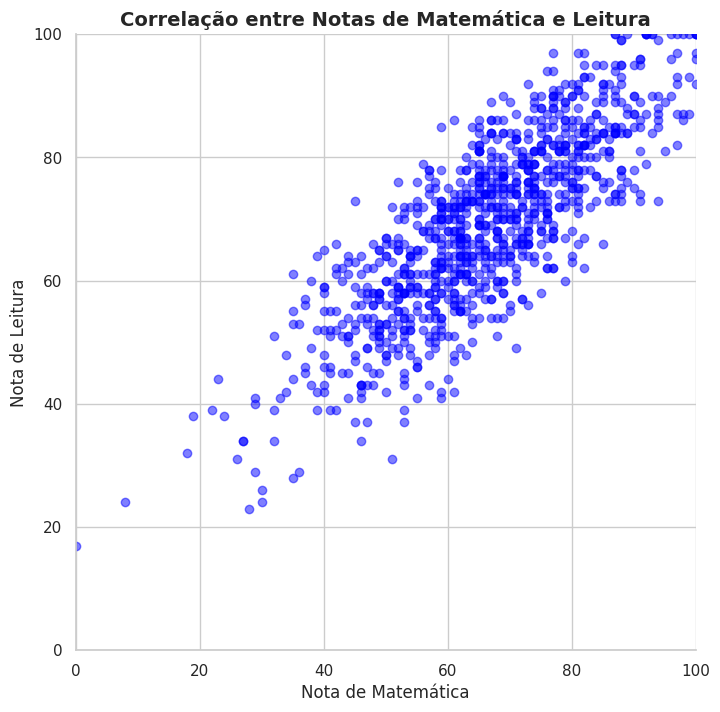

In [ ]:
# Dados para o Desafio 2.4
plt.figure(figsize=(8, 8))
plt.scatter(x=df_performance["math_score"], y=df_performance["reading_score"], alpha=0.5, color="blue")
plt.title("Correlação entre Notas de Matemática e Leitura", fontsize=14, fontweight="bold")
plt.xlabel("Nota de Matemática")
plt.ylabel("Nota de Leitura")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()

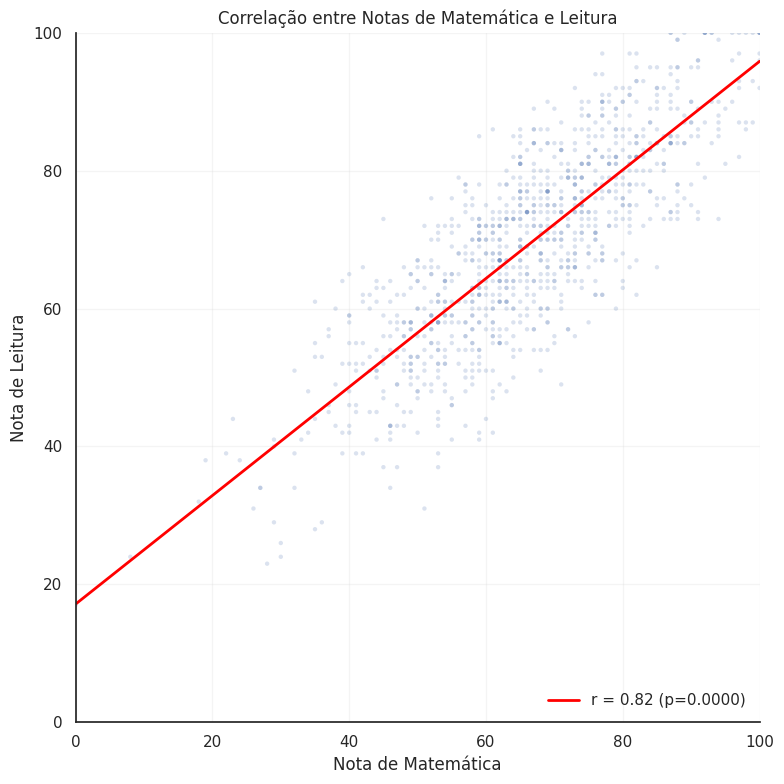

In [23]:
# 1. Problemas identificados:
#    a) Sobrecarga de pontos sobrepostos (overplotting) – Cleveland-McGill: alpha=0.5 ajuda, mas com centenas/milhares de pontos ainda há densidade escondida,
# regiões com muitos pontos (ex: notas 60-80) viram uma mancha azul homogênea e impossível saber onde há 10, 100 ou 500 pontos.
#    b) Perda de informação de densidade – Tufte: O gráfico mostra cada ponto, mas não mostra onde está a concentração
#    c) Falta de sumarização estatística: Sem linha de regressão (tendência central), sem coeficiente de correlação (força da relação)

# 2. Seu código Python refatorado:
fig, ax = plt.subplots(figsize=(8, 8))

# Pontos com alpha baixo + tamanho pequeno
ax.scatter(df_performance["math_score"], df_performance["reading_score"],
           alpha=0.2, s=10, color="#4C72B0", edgecolors='none')

# Linha de regressão
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_performance["math_score"], df_performance["reading_score"])
x_line = np.array([0, 100])
ax.plot(x_line, intercept + slope * x_line, color="red", linewidth=2,
        label=f"r = {r_value:.2f} (p={p_value:.4f})")

# Personalização
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_title("Correlação entre Notas de Matemática e Leitura")
ax.set_xlabel("Nota de Matemática"); ax.set_ylabel("Nota de Leitura")
ax.grid(True, alpha=0.2)
ax.legend(loc="lower right", frameon=False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Desafio 2.5: Desempenho Geral por Curso de Preparação (Gráfico de Pizza com Múltiplas Variáveis)

Cenário: Um conselheiro estudantil quer visualizar o impacto do curso de preparação (test_preparation_course) no desempenho geral dos alunos, mas o gráfico atual tenta mostrar muitas coisas de uma vez de forma ineficaz.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico, especialmente em relação ao uso do gráfico de pizza para comparar médias e à representação de múltiplas variáveis?

2. Modifique o código para criar uma visualização mais eficaz que compare o desempenho médio em cada matéria (não apenas a média geral) entre os alunos que completaram e os que não completaram o curso de preparação.

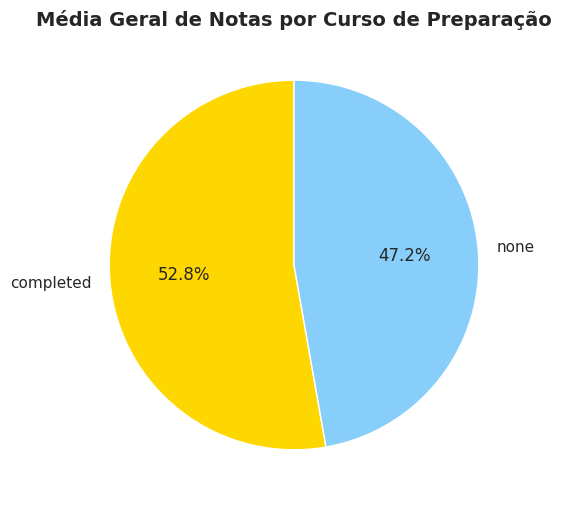

In [ ]:
# Dados para o Desafio 2.5
df_prep_course = df_performance.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score"]].mean().mean(axis=1).reset_index(name="overall_average_score")

plt.figure(figsize=(6, 6))
plt.pie(df_prep_course["overall_average_score"], labels=df_prep_course["test_preparation_course"], autopct="%1.1f%%", startangle=90, colors=["gold", "lightskyblue"])
plt.title("Média Geral de Notas por Curso de Preparação", fontsize=14, fontweight="bold")
plt.show()

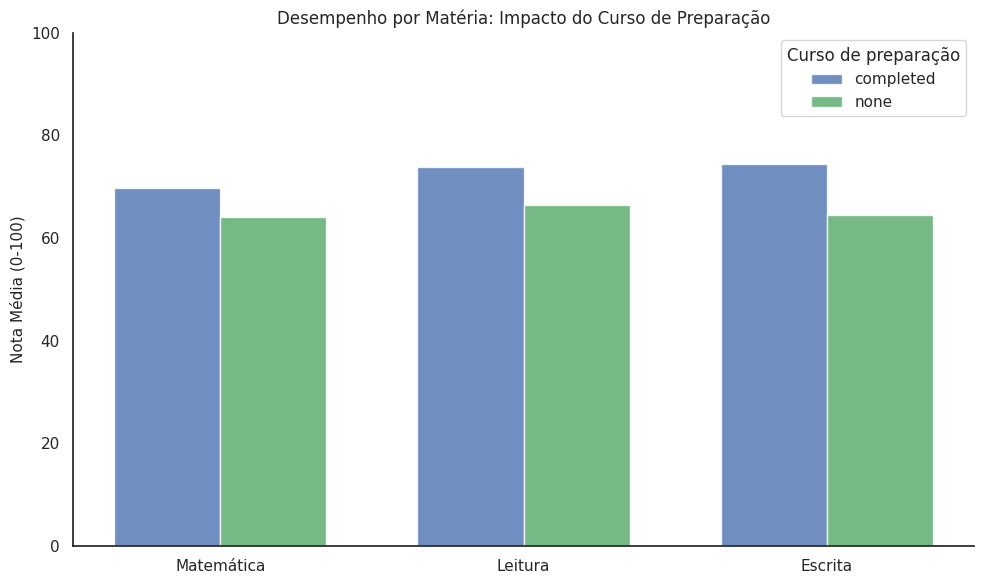

In [24]:
# 1. Problemas identificados:
#    a) Gráfico de pizza para comparar médias (erro categórico) – Cleveland-McGill: faz parecer que quem fez curso tem 52.8% de algo, quando a diferença real é pequena
#    b) Perda de informação das matérias individuais – Tufte: Fez .mean(axis=1) → média das 3 notas (math, reading, writing), joga fora diferenças importantes entre matérias,
#    exemplo: curso pode ajudar mais em matemática do que em escrita
#    c) Representação enganosa de proporção – Gestalt/Fechamento: Gráfico de pizza induz o cérebro a comparar áreas (fatias), áreas são difíceis de comparar
#    com precisão e para diferenças pequenas (~5%), pizza é terrível.

# 2. Seu código Python refatorado:
# Calcular médias por matéria
medias = df_performance.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score"]].mean().reset_index()

# Configuração
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(medias.columns[1:]))  # posições das matérias
width = 0.35  # largura das barras

# Barras para cada grupo
cursos = medias["test_preparation_course"].unique()
cores = ["#4C72B0", "#55A868"]

for i, curso in enumerate(cursos):
    valores = medias[medias["test_preparation_course"] == curso].iloc[0, 1:].values
    ax.bar(x + i*width, valores, width, label=curso, color=cores[i], alpha=0.8)

# Formatação
ax.set_ylabel("Nota Média (0-100)", fontsize=11)
ax.set_title("Desempenho por Matéria: Impacto do Curso de Preparação", fontsize=12)
ax.set_xticks(x + width/2)
ax.set_xticklabels(["Matemática", "Leitura", "Escrita"])
ax.set_ylim(0, 100)
ax.legend(title="Curso de preparação")
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()